In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
%pwd

'c:\\Users\\Yonas\\Desktop\\colorectal-survival-ml\\notebooks'

In [4]:
df = pd.read_csv("../Data/data.csv")

In [5]:
df.head()

,Patient_ID,Country,Age,Gender,Cancer_Stage,Tumor_Size_mm,Family_History,Smoking_History,Alcohol_Consumption,Obesity_BMI,...,Survival_5_years,Mortality,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K,Urban_or_Rural,Economic_Classification,Healthcare_Access,Insurance_Status,Survival_Prediction
0,1,UK,77,M,Localized,69,No,No,Yes,Overweight,...,Yes,No,54413,50,5,Urban,Developed,Moderate,Insured,Yes
1,2,UK,59,M,Localized,33,No,No,No,Overweight,...,Yes,No,76553,37,25,Urban,Developing,High,Uninsured,Yes
2,3,Japan,66,M,Regional,17,No,Yes,No,Normal,...,Yes,No,62805,54,27,Urban,Developed,Moderate,Uninsured,No
3,4,USA,83,M,Regional,14,No,No,No,Obese,...,Yes,No,89393,45,11,Urban,Developed,Moderate,Insured,Yes
4,5,France,66,M,Localized,34,No,Yes,No,Normal,...,Yes,No,66425,15,27,Urban,Developing,High,Insured,Yes


In [6]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'Cancer_Stage',
       'Tumor_Size_mm', 'Family_History', 'Smoking_History',
       'Alcohol_Consumption', 'Obesity_BMI', 'Diet_Risk', 'Physical_Activity',
       'Diabetes', 'Inflammatory_Bowel_Disease', 'Genetic_Mutation',
       'Screening_History', 'Early_Detection', 'Treatment_Type',
       'Survival_5_years', 'Mortality', 'Healthcare_Costs',
       'Incidence_Rate_per_100K', 'Mortality_Rate_per_100K', 'Urban_or_Rural',
       'Economic_Classification', 'Healthcare_Access', 'Insurance_Status',
       'Survival_Prediction'],
      dtype='str')

In [7]:
# the output 
df["Survival_Prediction"].value_counts()

Survival_Prediction
Yes    100437
No      67060
Name: count, dtype: int64

In [8]:
df.isnull().sum()

Patient_ID                    0
Country                       0
Age                           0
Gender                        0
Cancer_Stage                  0
Tumor_Size_mm                 0
Family_History                0
Smoking_History               0
Alcohol_Consumption           0
Obesity_BMI                   0
Diet_Risk                     0
Physical_Activity             0
Diabetes                      0
Inflammatory_Bowel_Disease    0
Genetic_Mutation              0
Screening_History             0
Early_Detection               0
Treatment_Type                0
Survival_5_years              0
Mortality                     0
Healthcare_Costs              0
Incidence_Rate_per_100K       0
Mortality_Rate_per_100K       0
Urban_or_Rural                0
Economic_Classification       0
Healthcare_Access             0
Insurance_Status              0
Survival_Prediction           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(167497, 28)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167497 entries, 0 to 167496
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   Patient_ID                  167497 non-null  int64
 1   Country                     167497 non-null  str  
 2   Age                         167497 non-null  int64
 3   Gender                      167497 non-null  str  
 4   Cancer_Stage                167497 non-null  str  
 5   Tumor_Size_mm               167497 non-null  int64
 6   Family_History              167497 non-null  str  
 7   Smoking_History             167497 non-null  str  
 8   Alcohol_Consumption         167497 non-null  str  
 9   Obesity_BMI                 167497 non-null  str  
 10  Diet_Risk                   167497 non-null  str  
 11  Physical_Activity           167497 non-null  str  
 12  Diabetes                    167497 non-null  str  
 13  Inflammatory_Bowel_Disease  167497 non-null  str  
 14 

In [12]:
df.describe()

,Patient_ID,Age,Tumor_Size_mm,Healthcare_Costs,Incidence_Rate_per_100K,Mortality_Rate_per_100K
count,167497.000000,167497.00000,167497.000000,167497.000000,167497.000000,167497.000000
mean,83749.000000,69.20078,42.005708,72452.168099,34.531562,17.023875
std,48352.363357,11.87247,21.672206,27402.779597,14.447970,7.208766
min,1.000000,30.00000,5.000000,25000.000000,10.000000,5.000000
25%,41875.000000,59.00000,23.000000,48760.000000,22.000000,11.000000
50%,83749.000000,69.00000,42.000000,72344.000000,35.000000,17.000000
75%,125623.000000,79.00000,61.000000,96227.000000,47.000000,23.000000
max,167497.000000,89.00000,79.000000,119999.000000,59.000000,29.000000


In [13]:
df.columns

Index(['Patient_ID', 'Country', 'Age', 'Gender', 'Cancer_Stage',
       'Tumor_Size_mm', 'Family_History', 'Smoking_History',
       'Alcohol_Consumption', 'Obesity_BMI', 'Diet_Risk', 'Physical_Activity',
       'Diabetes', 'Inflammatory_Bowel_Disease', 'Genetic_Mutation',
       'Screening_History', 'Early_Detection', 'Treatment_Type',
       'Survival_5_years', 'Mortality', 'Healthcare_Costs',
       'Incidence_Rate_per_100K', 'Mortality_Rate_per_100K', 'Urban_or_Rural',
       'Economic_Classification', 'Healthcare_Access', 'Insurance_Status',
       'Survival_Prediction'],
      dtype='str')

In [21]:
numerical_col = []
categorical_col = []

for col in df.columns :
    if df[col].dtypes == "int":
        numerical_col.append(col)
    else :
        categorical_col.append(col)

In [ ]:
#numerical_col = df.select_dtypes(include=["int64", "float64"]).columns.to_list()
#categorical_col = df.select_dtypes(include=["string"]).columns.to_list()

In [20]:
numerical_col

print(len(categorical_col))
print(len(numerical_col))

22
6


### VISUALIZATIONS


In [23]:
df["Cancer_Stage"].value_counts()

Cancer_Stage
Regional      66981
Localized     66799
Metastatic    33717
Name: count, dtype: int64

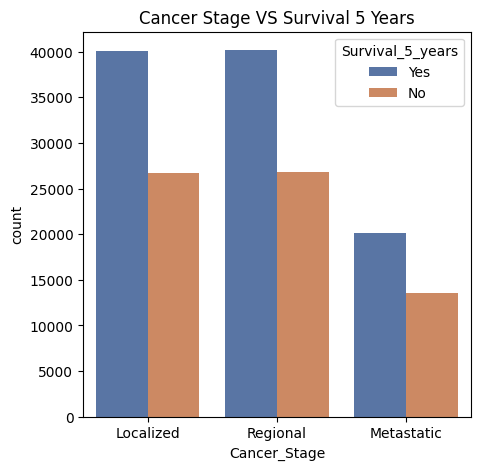

In [27]:
plt.figure(figsize=(5,5))
sns.countplot(x="Cancer_Stage" , hue="Survival_5_years" , data=df , palette="deep")
plt.title("Cancer Stage VS Survival 5 Years")
plt.show()

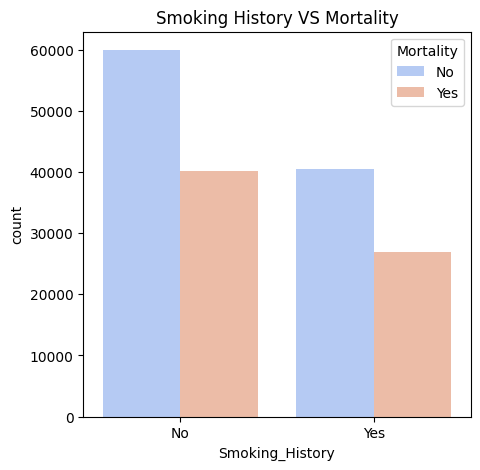

In [28]:
plt.figure(figsize=(5,5))
sns.countplot(x="Smoking_History" , hue="Mortality" , data=df , palette="coolwarm")
plt.title("Smoking History VS Mortality")
plt.show()

C:\Users\gusai\AppData\Local\Temp\ipykernel_15084\2536967357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cancer_Stage" , y="Tumor_Size_mm" , data=df ,palette="coolwarm" )


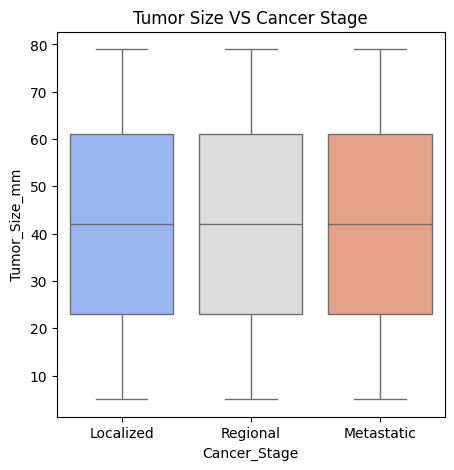

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(x="Cancer_Stage" , y="Tumor_Size_mm" ,  data=df ,palette="coolwarm" )
plt.title("Tumor Size VS Cancer Stage")
plt.show()

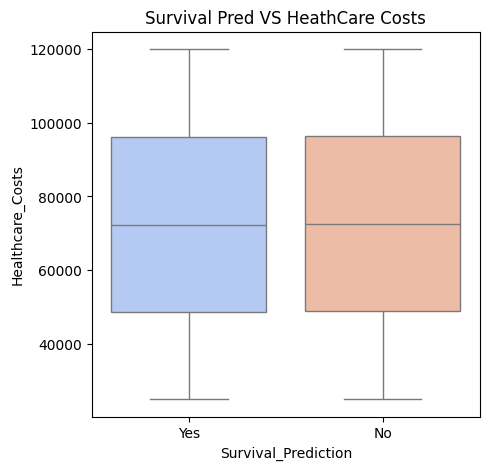

In [41]:
plt.figure(figsize=(5,5))
sns.boxplot(x="Survival_Prediction" , y="Healthcare_Costs" , hue="Survival_Prediction" , data=df ,palette="coolwarm" )
plt.title("Survival Pred VS HeathCare Costs")
plt.show()

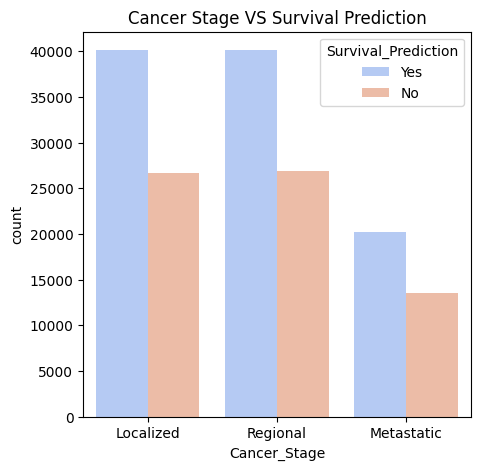

In [42]:
plt.figure(figsize=(5,5))
sns.countplot(x="Cancer_Stage" , hue="Survival_Prediction" , data=df , palette="coolwarm")
plt.title("Cancer Stage VS Survival Prediction")
plt.show()

### DATA PROCESSING

In [43]:
df = df.drop(columns=['Patient_ID'])

In [44]:
X = df.drop(columns=['Survival_Prediction'])
Y = df["Survival_Prediction"]

In [46]:
from sklearn.preprocessing import LabelEncoder

In [47]:
categorical_cols = X.select_dtypes(include=['object']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

C:\Users\Yonas\AppData\Local\Temp\ipykernel_26532\2530295040.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train , X_test , y_train , y_test = train_test_split(X,Y , test_size=0.2 , random_state=42)

In [50]:
from sklearn.feature_selection import chi2,SelectKBest

In [59]:
### CHI-SQUARe-TEST

X_cat = X_train.select_dtypes(include=['int64' , 'float64'])
chi2_selector = SelectKBest(score_func=chi2 , k="all")
chi2_selector.fit(X_cat,y_train)


SelectKBest(k='all', score_func=<function chi2 at 0x000001CB6A6B20C0>)

In [60]:
chi2_scores = pd.DataFrame({
    'Feature' : X_cat.columns,
    "Chi2 Score" : chi2_selector.scores_
}).sort_values(by='Chi2 Score' , ascending=False)

In [61]:
chi2_scores

,Feature,Chi2 Score
19,Healthcare_Costs,2097.430133
4,Tumor_Size_mm,7.971461
16,Treatment_Type,4.987144
11,Diabetes,2.103967
21,Mortality_Rate_per_100K,1.963077
25,Insurance_Status,1.464241
3,Cancer_Stage,1.281849
14,Screening_History,1.159519
0,Country,0.883425
24,Healthcare_Access,0.713346


In [62]:
top_features = chi2_scores.head(5)["Feature"].tolist()

In [64]:
X = X[top_features]

In [65]:
X.shape

(167497, 5)

In [68]:
X_train , X_test , y_train , y_test = train_test_split(X,Y , test_size=0.2 , random_state=42 , stratify=Y)

### MODEL BUILDING

In [70]:
from sklearn.preprocessing import StandardScaler

In [71]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

In [73]:
gb = GradientBoostingClassifier(n_estimators=100 , learning_rate=0.1 , max_depth=3 , random_state=42)

In [74]:
gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [75]:
y_pred = gb.predict(X_test)

In [79]:
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report

In [77]:
accuracy = accuracy_score(y_test , y_pred)

In [78]:
accuracy

0.5995223880597015

In [80]:
report = classification_report(y_test,y_pred)

In [82]:
print(report)

              precision    recall  f1-score   support

          No       0.44      0.00      0.00     13412
         Yes       0.60      1.00      0.75     20088

    accuracy                           0.60     33500
   macro avg       0.52      0.50      0.38     33500
weighted avg       0.54      0.60      0.45     33500



In [86]:
y_proba = gb.predict_proba(X_test)[ : , 1] if len(Y.unique())== 2 else None

In [87]:
roc_auc_score(y_test , y_proba)

np.float64(0.49967731082550826)

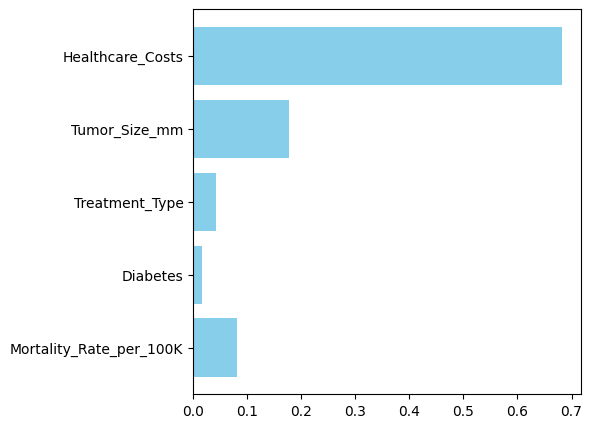

In [88]:
plt.figure(figsize=(5,5))
plt.barh(top_features , gb.feature_importances_ , color="skyblue")
plt.gca().invert_yaxis()
plt.show()

## TESTING

In [96]:
X.columns

Index(['Healthcare_Costs', 'Tumor_Size_mm', 'Treatment_Type', 'Diabetes',
       'Mortality_Rate_per_100K'],
      dtype='object')

In [94]:
test_array = np.array([0,0,0,0,0]).reshape(1,-1)

In [95]:
gb.predict(test_array)

array(['Yes'], dtype=object)

In [ ]:
#### Scaler...
###  Model ...